# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Camello, Zack Kenshin
- _Student No._: 2024-08825
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
$Function \ 1: f(x) = \sqrt{x^2 + x} - x$

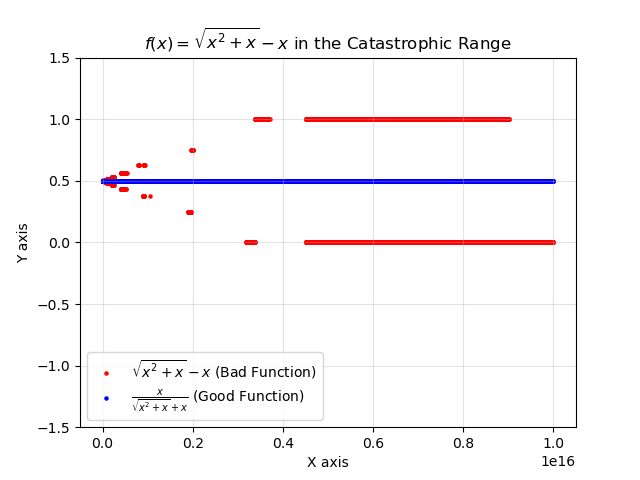
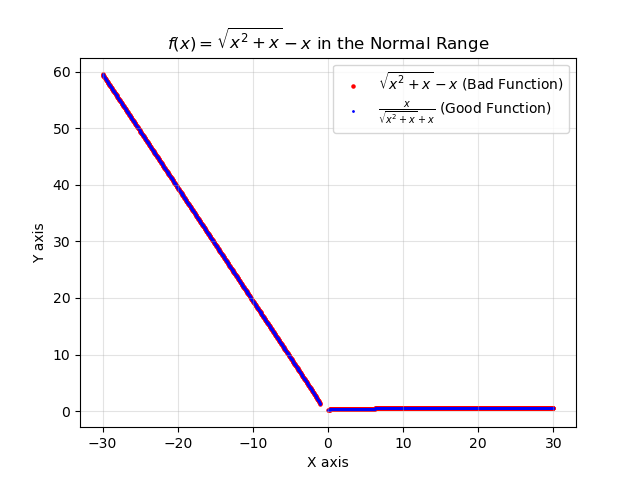

As shown in the two graphs above, catastrophic cancellation occurs at extremely large numbers. At lower numbers, either equations result into graphs which appear to follow the same form.

$Function \ 2: f(x) = \frac{e^x - 1}{x}$

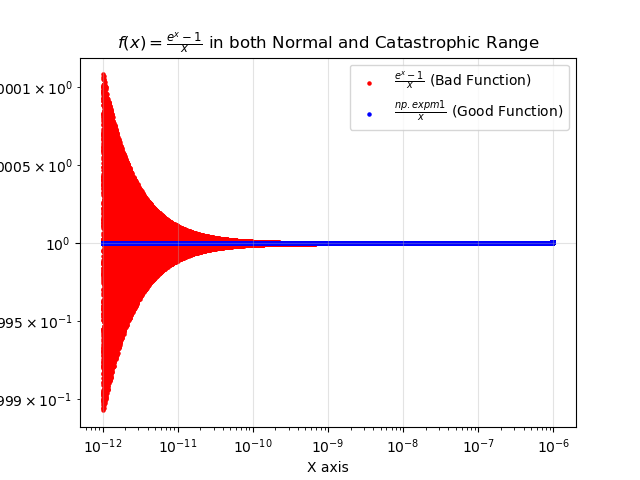

As shown in the graph above, instead of large numbers, catastrophic cancellation occurs at extremely small numbers instead. At extremely small values, the "bad" equation becomes unstable and results into a wide range of numbers. On the other hand, at larger values, both equations appear to follow the same shape.

### Report discussion
1. (Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
   
   The two formulas differ mainly in the fact of the absence or presence of subtraction. Because $b^2 \gg 4ac$ , the entire $\sqrt{b^2 - 4ac}$ term  $\approx b$. The "bad" formula then subtracts these two extremely similar numbers, which triggers the cancellation of the leading digits alongside inherent rounding errors, causing the result to become inaccurate and corrupted. By avoiding subtraction altogether, the code is able to bypass these limitations by mainly relying on multiplication and division.
    
3. (Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied?

   For the first function, as  $\lim_{x \to \infty} \sqrt{x^2 + x} - x$, it is expected to approach 0.5. At extremely large values of x however, $\sqrt{x^2 + x} \approx x$, thus causing two extremely similar values to be subtracted, leading to the catastrophic cancellation. This is remedied by multiplying the function by its conjugate, leading to the expression $x/(x + np.sqrt(x**2 + x))$.

   As for the second function, as  $\lim_{x \to \infty} \frac{e^x - 1}{x}$, it is expected to approach 1. At extremely small values of x however, $e^x \approx 1$, thus again leading to the subtraction of two extremely similar values, causing catastrophic cancellation to occur. This is remedied by removing the numerator entirely, and replacing it with the NumPy function $np.expm1(x)$, which evaluates $e^x - 1$ with higher precision.

### Other comments

## Section 2 (Problems and Code)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
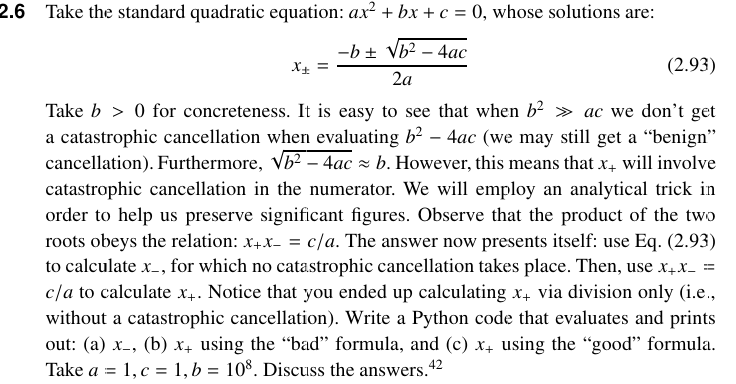

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

a = 1
b = 10**8
c = 1

def quadratic(a, b, c):
    xminus = (-b - np.sqrt((b**2)-(4*a*c)))/(2*a) #Calculates x-
    xplus = (-b + np.sqrt((b**2)-(4*a*c)))/(2*a) # Calculates x+ using "bad" formula
    xgood = a/(c*xminus) #Calcalates x+ using "good" formula
    check = (xminus*xgood == 1) #Checks whether the identity x-*x+ is equal to 1
    return xminus, xplus, xgood, check

print("x- = ", quadratic(a,b,c)[0])
print("Catastrophic x+ = ", quadratic(a,b,c)[1])
print("Good x+ = ", quadratic(a,b,c)[2])
print("Is x-*x+ = 1? ", quadratic(a,b,c)[3])

x- =  -100000000.0
Catastrophic x+ =  -7.450580596923828e-09
Good x+ =  -1e-08
Is x-*x+ = 1?  True


#### Problem 1 code summary

The code above simply calculates the roots of the quadratic equation $x^2 + 10^8x + 1$ using a simple function. It calculates x+ in two ways in particular, one avoiding subtraction, in order to avoid the catastrophic cancellation. As shown in the result, by using the "good" formula (one that does not involve subtraction), the code is able to successfully obtain two roots which when multiplied is equivalent to 1.


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

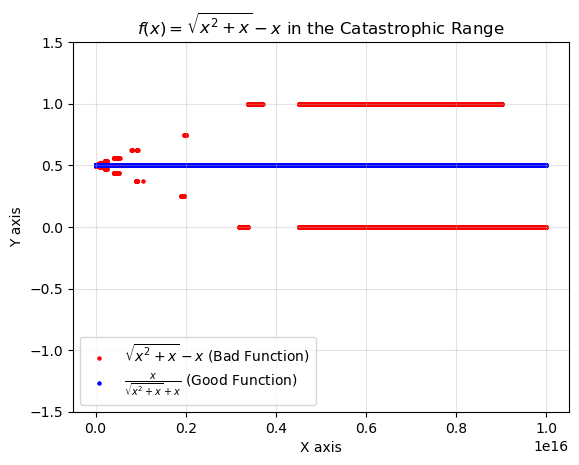

/tmp/ipykernel_2244221/1071265812.py:9: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(x**2 + x) - x #Original Function
/tmp/ipykernel_2244221/1071265812.py:12: RuntimeWarning: invalid value encountered in sqrt
  return x/(x + np.sqrt(x**2 + x)) #Remedied function by multiplying with conjugate


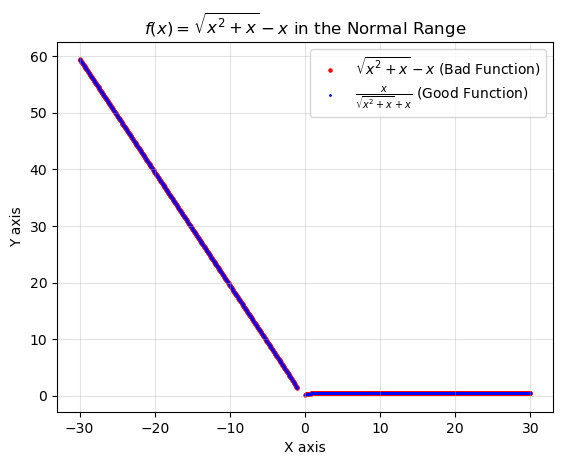

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math

x1 = np.logspace(9, 16, 100000)
x2 = np.linspace(-30, 30, 1000)

def badf(x): 
    return np.sqrt(x**2 + x) - x #Original Function
    
def goodf(x):
    return x/(x + np.sqrt(x**2 + x)) #Remedied function by multiplying with conjugate

plt.scatter(x1, badf(x1), label=r"$\sqrt{x^2 + x} - x$ (Bad Function)", c="red", s=5) #Graphs bad function in catastrophic range
plt.scatter(x1, goodf(x1), label=r"$\frac{x}{\sqrt{x^2 + x} + x}$ (Good Function)", c="blue", s=5) #Graphs good function in catastrophic range
plt.title(r"$f(x) = \sqrt{x^2 + x} - x$ in the Catastrophic Range")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha = 0.35)
plt.legend()
plt.savefig("Part 1 Catastrophic Range")
plt.show()

plt.scatter(x2, badf(x2), label=r"$\sqrt{x^2 + x} - x$ (Bad Function)", c="red", s=5) #Graphs bad function in normal range
plt.scatter(x2, goodf(x2), label=r"$\frac{x}{\sqrt{x^2 + x} + x}$ (Good Function)", c="blue", s=1) #Graphs good function in normal range
plt.title(r"$f(x) = \sqrt{x^2 + x} - x$ in the Normal Range")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.grid(True, alpha = 0.35)
plt.legend()
plt.savefig("Part 1 Normal Range")
plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



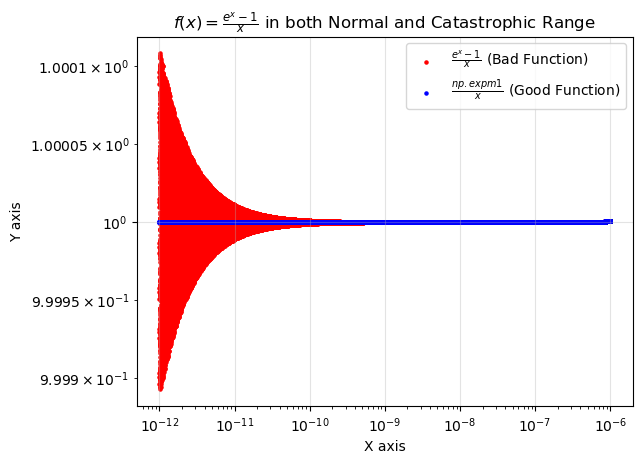

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.logspace(-12, -6, 100000)

def badf(x): 
    return (np.exp(x) - 1)/x #Original function
    
def goodf(x):
    return np.expm1(x)/x #Remedied function by making use of the available expm1 function of NumPy which simply calculates e^x - 1 with higher precision

plt.scatter(x, badf(x), label=r"$\frac{e^x - 1}{x}$ (Bad Function)", c="red", s=5) #Graphs bad function in both normal and catastrophic range
plt.scatter(x, goodf(x), label=r"$\frac{np.expm1}{x}$ (Good Function)", c="blue", s=5) #Grapsh good function in both normal and catastrophic range
plt.title(r"$f(x) = \frac{e^x - 1}{x}$ in both Normal and Catastrophic Range")
plt.xlabel("X axis")
plt.xscale("log") #Changes the x axis to be a log scale
plt.ylabel("Y axis")
plt.yscale("log") #Changes the y axis to be a log scale
plt.grid(True, alpha = 0.35)
plt.legend()
plt.savefig("Part 2 Catastrophic and Normal Range")
plt.show()

#### Problem 2 code summary

The code above simply calculates the values of $f(x) = \frac{e^x - 1}{x}$ in two differing expressions of the same function. As shown above, when using the "bad" function, the values of f(x) become unstable at extremely low values. This is due to the fact that at this point $e^x \approx 1$, leading to the subtraction of two extremely similar numbers, and thus causing catastrophic cancellation to occur. By using NumPy's specialized code in solving $e^x - 1$, we are able to avoid subtraction while simultaneously calculate these values with higher precision. 

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
